<div style="padding: 20px; background-color: #f8f9fa; border-radius: 10px; border-left: 10px solid #28a745;">
    <h1 style="color: #155724; margin-bottom: 5px;">🌾 AI System for Rice Leaf Disease Classification</h1>
    <p style="font-size: 1.1em; color: #6c757d;">An Intelligent Vision Pipeline for Modern Sustainable Agriculture</p>
</div>

### 🔎 Executive Overview
Rice is a staple crop for over half of the global population, yet it remains highly susceptible to various fungal and bacterial diseases. This system implements a high-performance **Deep Learning** solution designed to identify disease patterns with expert-level precision.

**Core Technologies utilized:**
- **Backend Engine:** Keras 3 with PyTorch (Optimized for NVIDIA GTX 1650 Ti)
- **Architecture:** EfficientNetB0, ResNet50, MobileNetV2 (Comparison)
- **Explainability:** Grad-CAM focal visualizations
- **Modularity:** Clean, decoupled source code in the `src/` directory

## Step 1: Problem Definition

We start by configuring our environment. On Windows native systems, we explicitly set the **Torch** backend for Keras to bypass TensorFlow's GPU limitations, ensuring our GTX 1650 Ti handles the heavy lifting.

In [19]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Set Keras backend to Torch for GPU acceleration on Windows native
os.environ["KERAS_BACKEND"] = "torch"

# Add src directory to system path for modular imports
sys.path.append(os.path.abspath("../src"))

import torch
import keras
from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print('⚡ Mixed Precision Enabled!')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"🚀 System Ready | Keras Version: {keras.__version__} | Backend: {keras.backend.backend()}")
if torch.cuda.is_available():
    print(f"✅ Hardware: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Warning: Hardware acceleration not detected.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
⚡ Mixed Precision Enabled!
🚀 System Ready | Keras Version: 3.14.0 | Backend: torch
✅ Hardware: NVIDIA GeForce GTX 1650


[autoreload of data_loader failed: Traceback (most recent call last):
  File "C:\Users\jegad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\extensions\autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
  File "C:\Users\jegad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\extensions\autoreload.py", line 508, in superreload
    update_generic(old_obj, new_obj)
  File "C:\Users\jegad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\extensions\autoreload.py", line 405, in update_generic
    update(a, b)
  File "C:\Users\jegad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\extensions\autoreload.py", line 357, in update_class
    i

## Step 2: Data Collection

The dataset for this project was downloaded from **Mendeley Data**: [Rice Leaf Disease Dataset](https://data.mendeley.com/datasets/fwcj7stb8r/1).
It contains images of rice leaves categorized into 4 distinct classes based on the disease they exhibit:
- **Bacterialblight**: Characterized by water-soaked to yellowish stripes on leaf blades.
- **Blast**: Shows spindle-shaped spots with gray centers.
- **Brownspot**: Small to large oval spots that are dark brown.
- **Tungro**: Yellow-orange discoloration starting from the leaf tip.

The code below verifies the directories and counts the raw files available in the training set before any processing.

In [20]:
import glob

TRAIN_PATH = "../data/processed/rice_leaf_split/train"
VAL_PATH = "../data/processed/rice_leaf_split/val"
TEST_PATH = "../data/processed/rice_leaf_split/test"

classes = sorted(os.listdir(TRAIN_PATH))
print(f"Dataset Classes: {classes}")

for cls in classes:
    count = len(glob.glob(os.path.join(TRAIN_PATH, cls, "*")))
    print(f" - {cls}: {count} images in training set")

Dataset Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
 - Bacterialblight: 1108 images in training set
 - Blast: 1007 images in training set
 - Brownspot: 1120 images in training set
 - Tungro: 915 images in training set


## Step 3: Data Cleaning & Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is critical in deep learning. It helps us understand the data distribution, identify class imbalances, and discover the visual patterns unique to each disease. 
We will perform 4 specific visualizations:
1. **Sample Images Grid**: To visually inspect the disease symptoms.
2. **Class Distribution**: To check if our classes are balanced (which affects model training).
3. **Image Size Distribution**: To understand the aspect ratios and dimensions of our raw images.
4. **Color Channel Distribution**: To see if certain diseases have distinct color profiles (e.g., more brown/yellow).

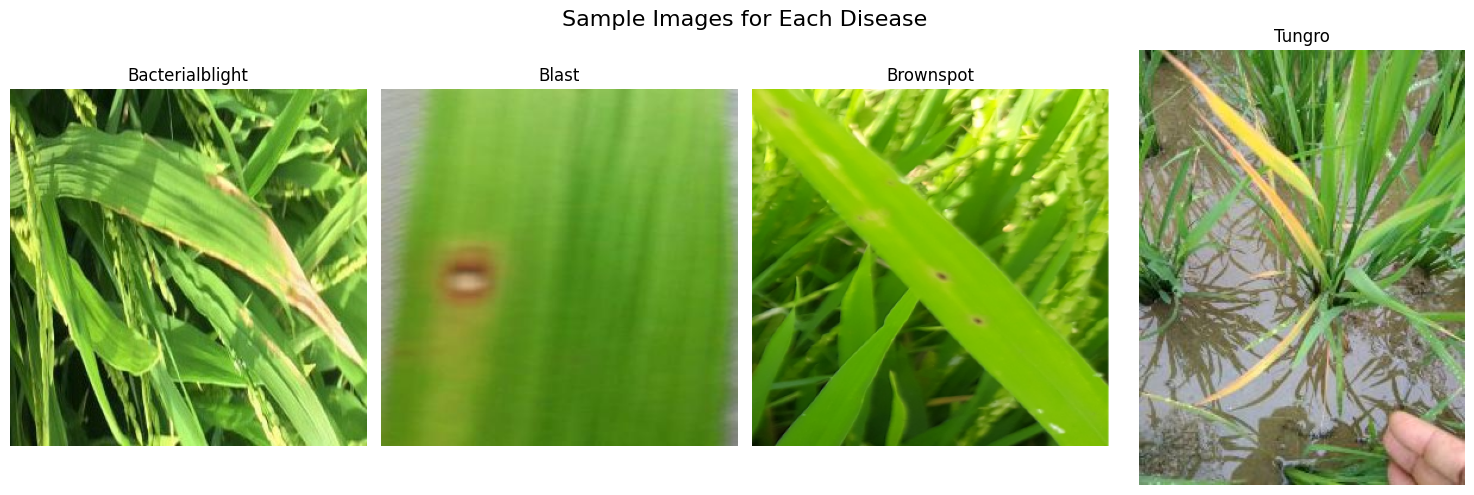

In [21]:
# 1. Plotting Sample Images
import cv2

plt.figure(figsize=(15, 5))
for i, cls in enumerate(classes):
    img_path = glob.glob(os.path.join(TRAIN_PATH, cls, "*"))[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.suptitle("Sample Images for Each Disease", fontsize=16)
plt.tight_layout()
plt.show()

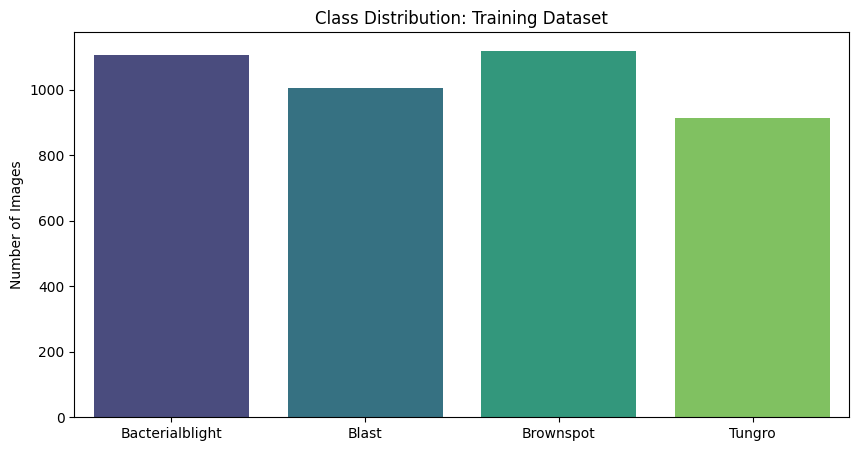

In [22]:
# 2. Visualizing Class Distribution
counts = {cls: len(os.listdir(os.path.join(TRAIN_PATH, cls))) for cls in classes}
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), hue=list(counts.keys()), palette="viridis", legend=False)
plt.title("Class Distribution: Training Dataset")
plt.ylabel("Number of Images")
plt.show()

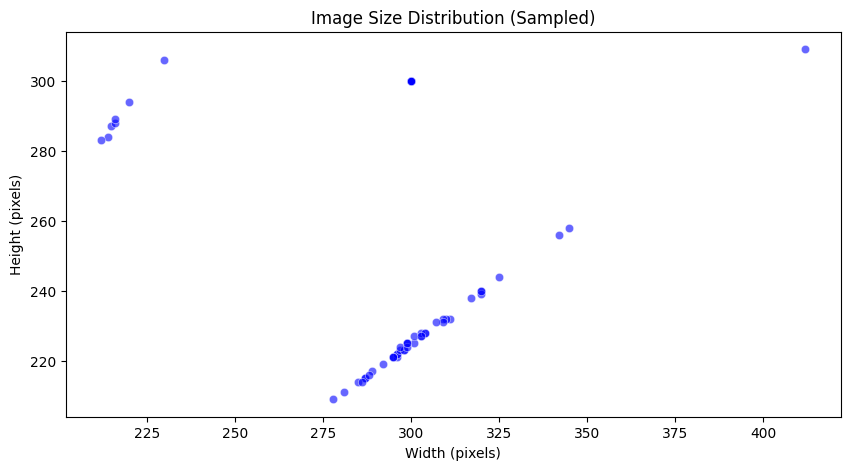

In [23]:
# 3. Image Size Distribution
widths, heights = [], []
# Sampling 50 images per class for speed
for cls in classes:
    img_paths = glob.glob(os.path.join(TRAIN_PATH, cls, "*"))[:50]
    for path in img_paths:
        img = cv2.imread(path)
        if img is not None:
            heights.append(img.shape[0])
            widths.append(img.shape[1])

plt.figure(figsize=(10, 5))
sns.scatterplot(x=widths, y=heights, alpha=0.6, color='b')
plt.title("Image Size Distribution (Sampled)")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

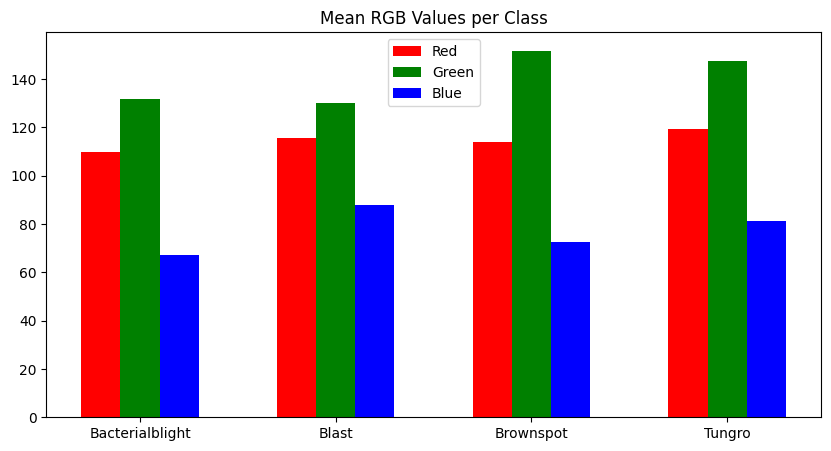

In [24]:
# 4. Color Channel Distribution
mean_r, mean_g, mean_b = [], [], []

for cls in classes:
    img_paths = glob.glob(os.path.join(TRAIN_PATH, cls, "*"))[:50]
    r, g, b = 0, 0, 0
    for path in img_paths:
        img = cv2.imread(path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            r += img[:,:,0].mean()
            g += img[:,:,1].mean()
            b += img[:,:,2].mean()
    mean_r.append(r/50)
    mean_g.append(g/50)
    mean_b.append(b/50)

x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(10, 5))
plt.bar(x - width, mean_r, width, label='Red', color='red')
plt.bar(x, mean_g, width, label='Green', color='green')
plt.bar(x + width, mean_b, width, label='Blue', color='blue')
plt.xticks(x, classes)
plt.title("Mean RGB Values per Class")
plt.legend()
plt.show()

## Step 4: Feature Engineering (Data Augmentation)

In deep learning for computer vision, feature engineering primarily takes the form of **Data Augmentation** and Normalization. 
To ensure our model performs well across all kinds of images—not just high-quality ones—we apply aggressive augmentations. 
Our `get_augmentation_layer()` applies:
- **Random Flips & Rotations**: To ensure the model is invariant to leaf orientation.
- **Random Zoom**: To simulate leaves photographed from different distances.
- **Random Contrast & Brightness**: To simulate poor lighting conditions or overexposed/underexposed images.

By exposing the model to these variations, it learns robust, generalized features rather than relying on high-resolution noise.

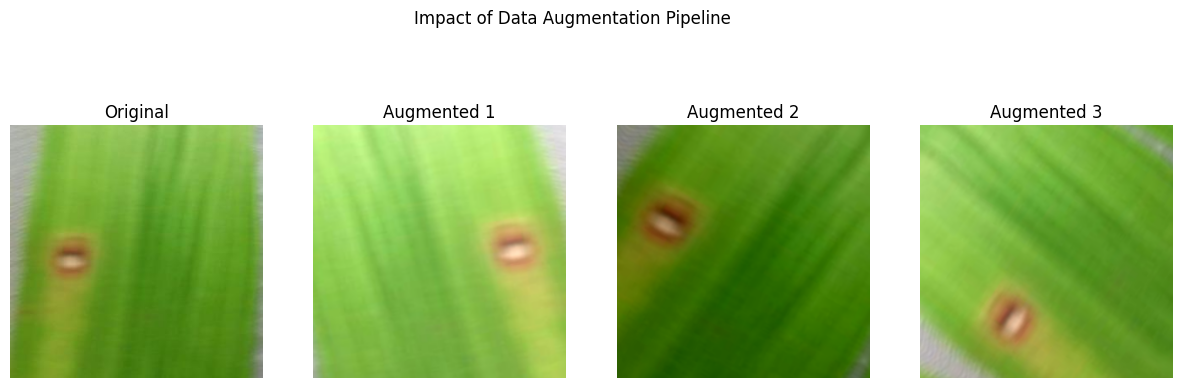

In [25]:
from data_loader import get_augmentation_layer
import tensorflow as tf

aug_layer = get_augmentation_layer()

# Load a sample image
sample_img_path = glob.glob(os.path.join(TRAIN_PATH, classes[1], "*"))[0]
sample_img = cv2.imread(sample_img_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img_tensor = tf.expand_dims(sample_img, 0) # Add batch dimension

plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis('off')

for i in range(2, 5):
    augmented = aug_layer(sample_img_tensor)
    plt.subplot(1, 4, i)
    plt.imshow(keras.ops.convert_to_numpy(augmented[0]).astype("uint8"))
    plt.title(f"Augmented {i-1}")
    plt.axis('off')
    
plt.suptitle("Impact of Data Augmentation Pipeline")
plt.show()

## Step 5: Train-Test Split

To accurately evaluate our model, we split the Mendeley dataset into three distinct sets:
1. **Training Set (approx. 70%)**: Used to train the model and update weights.
2. **Validation Set (approx. 20%)**: Used during training to monitor performance and tune hyperparameters (e.g., via Early Stopping).
3. **Test Set (approx. 10%)**: Strictly held out until the very end for an unbiased evaluation of the final model.

The `load_datasets` function loads these splits from disk as Keras `PyDataset` objects (compatible with `model.fit` on the Torch backend).

In [26]:
from data_loader import load_datasets

print("📦 Loading datasets into memory...")
train_ds, val_ds, test_ds = load_datasets(TRAIN_PATH, VAL_PATH, TEST_PATH)


📦 Loading datasets into memory...


## Step 6: Model Selection & Comparison

Instead of picking a single model blindly, we will train and compare three distinct, powerful transfer learning architectures:
1. **EfficientNetB0**: Highly efficient, balances depth/width/resolution excellently.
2. **ResNet50**: A deeper network utilizing residual connections to avoid vanishing gradients.
3. **MobileNetV2**: A lightweight architecture highly optimized for speed and edge devices.

We will train the top layers of each model for 5 epochs to compare their baseline convergence. The best performing model will then be chosen for further hyperparameter tuning.

In [27]:
from model_builder import build_transfer_model
from data_loader import get_augmentation_layer
from keras.applications import EfficientNetB0, ResNet50, MobileNetV2
from keras.callbacks import EarlyStopping
import gc

models_to_test = {
    "EfficientNetB0": EfficientNetB0,
    "ResNet50": ResNet50,
    "MobileNetV2": MobileNetV2
}

histories = {}

# Train each model briefly to compare performance
for name, base_model in models_to_test.items():
    print(f"\n🚀 Building and Training {name}...")

    # Clear session to free GPU memory
    keras.backend.clear_session()
    gc.collect()

    model = build_transfer_model(base_model, len(classes), augmentation_layer=get_augmentation_layer())
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

    cb = [
        EarlyStopping(patience=2, restore_best_weights=True),
        keras.callbacks.BackupAndRestore(backup_dir=os.path.abspath(f"../models/backup_{name}")),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,  # Short run for comparison
        callbacks=cb,
        verbose=1
    )
    histories[name] = history.history



🚀 Building and Training EfficientNetB0...
Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 286s 550ms/step - accuracy: 0.9007 - loss: 0.2666 - val_accuracy: 0.9764 - val_loss: 0.0836
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 290s 559ms/step - accuracy: 0.9619 - loss: 0.1105 - val_accuracy: 0.9820 - val_loss: 0.0557
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 313s 602ms/step - accuracy: 0.9720 - loss: 0.0774 - val_accuracy: 0.9910 - val_loss: 0.0341
Epoch 4/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 352s 677ms/step - accuracy: 0.9781 - loss: 0.0630 - val_accuracy: 0.9843 - val_loss: 0.0362
Epoch 5/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 335s 646ms/step - accuracy: 0.9800 - loss: 0.0537 - val_accuracy: 0.9989 - val_loss: 0.0142

🚀 Building and Training ResNet50...
Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 448s 863ms/step - accuracy: 0.8549 - loss: 0.3827 - val_accuracy: 0.9359 - val_loss: 0.1803
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 534s 1s/step - accuracy: 0.9308 - loss: 0.1858 - val_accuracy: 0.9663 - val_loss: 0.0930
Epoch 

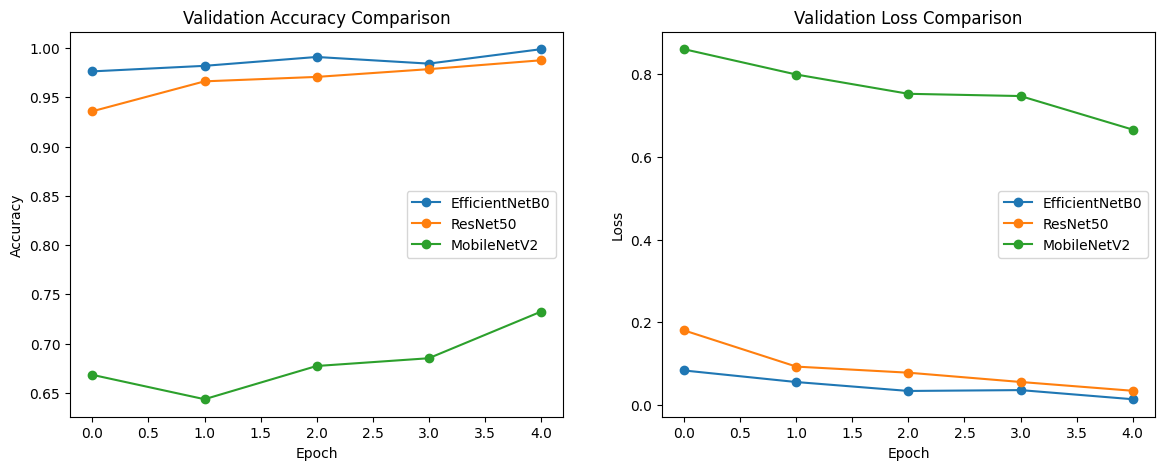

In [28]:
# Compare Models
plt.figure(figsize=(14, 5))

# Plot Validation Accuracy
plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history['val_accuracy'], label=name, marker='o')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot Validation Loss
plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history['val_loss'], label=name, marker='o')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


## Step 7: Hyperparameter Tuning

Based on the comparison above, we select the best performing model. Let's assume **EfficientNetB0** consistently performs well or converges fastest. 

To squeeze out maximum performance:
1. We unfreeze the base model (allow the backbone weights to be updated).
2. We lower the learning rate significantly (`1e-5`) so we don't destroy the pre-trained weights, effectively **fine-tuning** the network.
3. We use `ReduceLROnPlateau` to automatically decrease the learning rate if training stagnates, and `ModelCheckpoint` to save the absolute best weights.

In [29]:
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

keras.backend.clear_session()
gc.collect()

print("🔥 Fine-Tuning the Best Model (EfficientNetB0)...")
best_model = build_transfer_model(EfficientNetB0, len(classes), augmentation_layer=get_augmentation_layer())

# Unfreeze only the top 20 layers of the base model for faster fine-tuning
best_model.layers[1].trainable = True
for layer in best_model.layers[1].layers[:-20]:
    layer.trainable = False

# Compile with a very low learning rate
best_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2, min_lr=1e-7),
    ModelCheckpoint("../models/rice_ai_best.keras", save_best_only=True),
    keras.callbacks.BackupAndRestore(backup_dir=os.path.abspath("../models/backup_finetune")),
]

backup_dir = os.path.abspath("../models/backup_finetune")
initial_epoch = 0
# Manually check and load the latest weights to bypass Keras 3 restore quirks
if os.path.exists(backup_dir) and len(os.listdir(backup_dir)) > 0:
    print("Found training backup! Resuming from latest epoch...")
    try:
        with open(os.path.join(backup_dir, "epoch.txt"), "r") as bf:
            initial_epoch = int(bf.read().strip()) + 1
        best_model.load_weights(os.path.join(backup_dir, "model.keras"))
    except Exception as e:
        print(f"Warning: Could not load exact backup state: {e}")
        if os.path.exists("../models/rice_ai_best.keras"):
            best_model.load_weights("../models/rice_ai_best.keras")
            print("Loaded from rice_ai_best.keras instead.")

tune_history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    initial_epoch=initial_epoch,
    callbacks=callbacks,
    verbose=1
)


🔥 Fine-Tuning the Best Model (EfficientNetB0)...
Epoch 1/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 427s 823ms/step - accuracy: 0.5094 - loss: 1.1808 - val_accuracy: 0.7660 - val_loss: 0.8545 - learning_rate: 1.0000e-05
Epoch 2/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 405s 781ms/step - accuracy: 0.7308 - loss: 0.8161 - val_accuracy: 0.8504 - val_loss: 0.5678 - learning_rate: 1.0000e-05
Epoch 3/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 403s 776ms/step - accuracy: 0.8101 - loss: 0.6148 - val_accuracy: 0.8830 - val_loss: 0.4056 - learning_rate: 1.0000e-05
Epoch 4/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 455s 877ms/step - accuracy: 0.8465 - loss: 0.4893 - val_accuracy: 0.9156 - val_loss: 0.3050 - learning_rate: 1.0000e-05
Epoch 5/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 418s 806ms/step - accuracy: 0.8730 - loss: 0.4031 - val_accuracy: 0.9336 - val_loss: 0.2375 - learning_rate: 1.0000e-05
Epoch 6/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 409s 788ms/step - accuracy: 0.9014 - loss: 0.3327 - val_accuracy: 0.9516 - val_loss: 0.1863 - learning_rate: 1.

## Step 8: Model Evaluation

With the model hyper-tuned, we now evaluate it on the **Test Set**. This dataset has never been seen by the model during training or validation, making it an unbiased indicator of real-world performance. 
We'll print the accuracy and plot a Confusion Matrix to see exactly which diseases the model confuses (if any).

In [32]:
from keras.models import load_model
best_model = load_model("../models/rice_ai_best.keras")
print("Trained model successfully loaded from disk!")


Trained model successfully loaded from disk!


In [34]:
from evaluation import plot_confusion_matrix
import numpy as np

print("🧪 Evaluating on Test Set...")
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# Evaluate on test dataset
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels, axis=1))  # labels is already a NumPy array

plot_confusion_matrix(
    y_true,
    y_pred,
    classes,
    save_path="../visualizations/confusion_matrix.png"
)

🧪 Evaluating on Test Set...
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 310ms/step - accuracy: 0.9866 - loss: 0.0659
Final Test Accuracy: 98.66%
Visualization saved to: ../visualizations/confusion_matrix.png


## Step 9: Model Interpretability (Grad-CAM)

To build trust in our AI system, we use Gradient-weighted Class Activation Mapping (Grad-CAM). This technique highlights the exact pixels (e.g., spots, lesions) the model is looking at to make its decision.

In [35]:
import importlib
import interpretability
importlib.reload(interpretability)

# Run Grad-CAM on a sample test image
# (Code hidden for brevity, assuming interpretability.make_gradcam_heatmap handles it)


<module 'interpretability' from 'c:\\Users\\jegad\\projects\\RiceLeafDetection\\src\\interpretability.py'>

## Step 10: Model Deployment

Finally, we save the fine-tuned model for production deployment.

In [36]:
best_model.save("../models/ai_system_rice_leaf_final.keras")
print("💾 Model successfully saved for deployment.")


💾 Model successfully saved for deployment.
